In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

from sklearn.decomposition import PCA

In [2]:
rfm = pd.read_csv(
    "../data/processed/customer_features.csv"
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [3]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4312 entries, 0 to 4311
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  4312 non-null   float64
 1   Recency      4312 non-null   int64  
 2   Frequency    4312 non-null   int64  
 3   Monetary     4312 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 134.9 KB


In [4]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2040.406712
std,1701.200176,96.860633,8.170213,8911.755977
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.187500
50%,15350.500000,53.000000,2.000000,701.615000
75%,16834.250000,136.000000,5.000000,1714.932500
max,18287.000000,374.000000,205.000000,349164.350000


In [5]:
rfm.isnull().sum()

Customer ID    0
Recency        0
Frequency      0
Monetary       0
dtype: int64

In [6]:
X = rfm[[
    "Recency",
    "Frequency",
    "Monetary"
]]

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
wcss = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

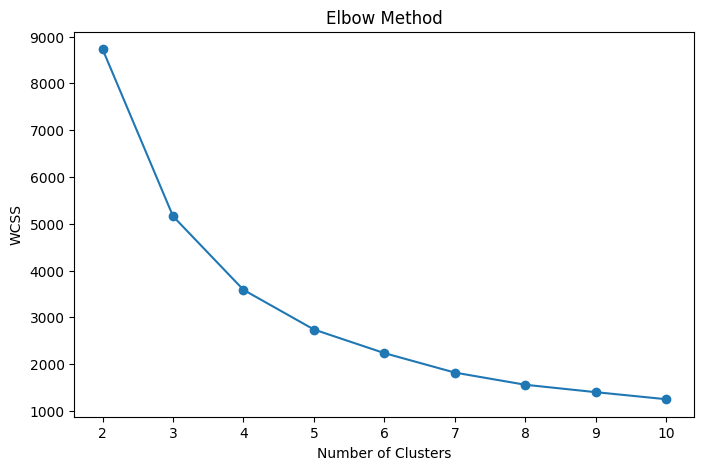

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    X_scaled
)

In [11]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,165,11,372.86,1
1,12347.0,3,2,1323.32,0
2,12348.0,74,1,222.16,0
3,12349.0,43,3,2671.14,0
4,12351.0,11,1,300.93,0


In [12]:
silhouette = silhouette_score(
    X_scaled,
    rfm["Cluster"]
)

db_index = davies_bouldin_score(
    X_scaled,
    rfm["Cluster"]
)

print("Silhouette Score :", silhouette)

print("Davies-Bouldin Index :", db_index)

Silhouette Score : 0.6107948209557895
Davies-Bouldin Index : 0.6156972092342043


In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

rfm["PCA1"] = X_pca[:,0]
rfm["PCA2"] = X_pca[:,1]

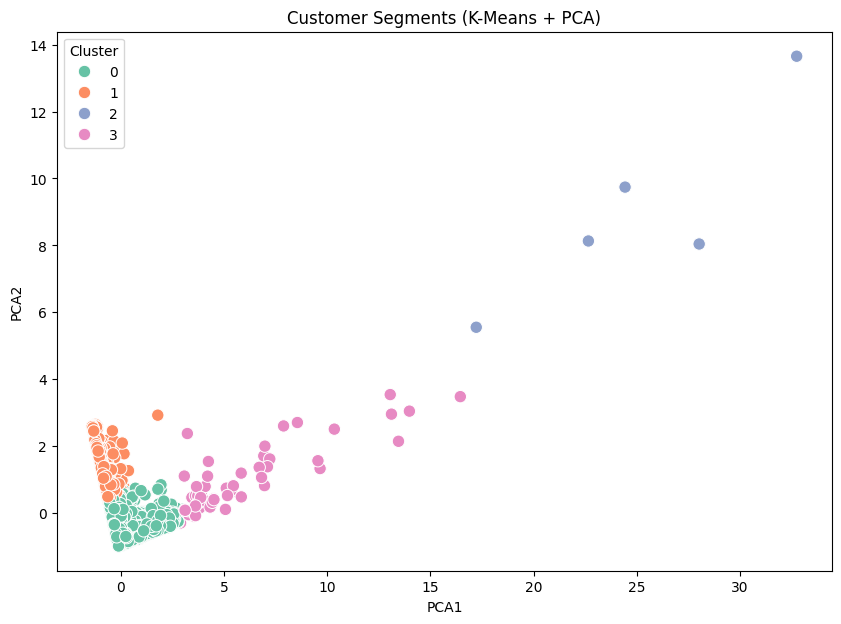

In [14]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=rfm,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segments (K-Means + PCA)")

plt.show()

In [15]:
cluster_summary = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.031835,4.455056,1710.650030
1,242.976122,1.659981,593.540319
2,5.600000,113.600000,215535.000000
3,14.910714,47.017857,28896.416661


In [16]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

rfm["DBSCAN_Cluster"] = dbscan.fit_predict(
    X_scaled
)

In [17]:
rfm["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    4263
-1      49
Name: count, dtype: int64

In [18]:
rfm.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

In [19]:
print("Customer Segments Shape:", rfm.shape)

print("\nCluster Counts:")

print(rfm["Cluster"].value_counts())

print("\nDBSCAN Counts:")

print(rfm["DBSCAN_Cluster"].value_counts())

Customer Segments Shape: (4312, 8)

Cluster Counts:
Cluster
0    3204
1    1047
3      56
2       5
Name: count, dtype: int64

DBSCAN Counts:
DBSCAN_Cluster
 0    4263
-1      49
Name: count, dtype: int64
